In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
ml_naive = pd.read_csv(
    "../data/processed/ml_dataset_naive.csv"
)

ml_corrected = pd.read_csv(
    "../data/processed/ml_dataset_corrected.csv"
)

print(ml_naive.shape)
print(ml_corrected.shape)

(2525, 11)
(2525, 12)


In [3]:
X_naive = ml_naive.drop(
    columns=[
        "genus",
        "interval",
        "survived"
    ]
)

y_naive = ml_naive["survived"]

print(X_naive.shape)

(2525, 8)


In [4]:
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_naive,
    y_naive,
    test_size=0.20,
    random_state=42,
    stratify=y_naive
)

In [5]:
lr_naive = LogisticRegression(
    max_iter=3000
)

lr_naive.fit(
    Xn_train,
    yn_train
)

pred_lr_naive = lr_naive.predict(
    Xn_test
)

prob_lr_naive = lr_naive.predict_proba(
    Xn_test
)[:,1]

In [6]:
rf_naive = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_naive.fit(
    Xn_train,
    yn_train
)

pred_rf_naive = rf_naive.predict(
    Xn_test
)

prob_rf_naive = rf_naive.predict_proba(
    Xn_test
)[:,1]

In [7]:
naive_results = pd.DataFrame({
    "Model":[
        "Logistic_Naive",
        "RandomForest_Naive"
    ],

    "Accuracy":[
        accuracy_score(
            yn_test,
            pred_lr_naive
        ),

        accuracy_score(
            yn_test,
            pred_rf_naive
        )
    ],

    "ROC_AUC":[
        roc_auc_score(
            yn_test,
            prob_lr_naive
        ),

        roc_auc_score(
            yn_test,
            prob_rf_naive
        )
    ]
})

naive_results

,Model,Accuracy,ROC_AUC
0,Logistic_Naive,0.762376,0.866630
1,RandomForest_Naive,0.720792,0.820288


In [8]:
X_corr = ml_corrected.drop(
    columns=[
        "genus",
        "interval",
        "survived"
    ]
)

y_corr = ml_corrected["survived"]

print(X_corr.shape)

(2525, 9)


In [9]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_corr,
    y_corr,
    test_size=0.20,
    random_state=42,
    stratify=y_corr
)

In [10]:
lr_corr = LogisticRegression(
    max_iter=3000
)

lr_corr.fit(
    Xc_train,
    yc_train
)

pred_lr_corr = lr_corr.predict(
    Xc_test
)

prob_lr_corr = lr_corr.predict_proba(
    Xc_test
)[:,1]

In [11]:
rf_corr = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_corr.fit(
    Xc_train,
    yc_train
)

pred_rf_corr = rf_corr.predict(
    Xc_test
)

prob_rf_corr = rf_corr.predict_proba(
    Xc_test
)[:,1]

In [12]:
corrected_results = pd.DataFrame({
    "Model":[
        "Logistic_Corrected",
        "RandomForest_Corrected"
    ],

    "Accuracy":[
        accuracy_score(
            yc_test,
            pred_lr_corr
        ),

        accuracy_score(
            yc_test,
            pred_rf_corr
        )
    ],

    "ROC_AUC":[
        roc_auc_score(
            yc_test,
            prob_lr_corr
        ),

        roc_auc_score(
            yc_test,
            prob_rf_corr
        )
    ]
})

corrected_results

,Model,Accuracy,ROC_AUC
0,Logistic_Corrected,0.782178,0.891389
1,RandomForest_Corrected,0.728713,0.826424


In [13]:
all_results = pd.concat([
    naive_results,
    corrected_results
])

all_results

,Model,Accuracy,ROC_AUC
0,Logistic_Naive,0.762376,0.866630
1,RandomForest_Naive,0.720792,0.820288
0,Logistic_Corrected,0.782178,0.891389
1,RandomForest_Corrected,0.728713,0.826424


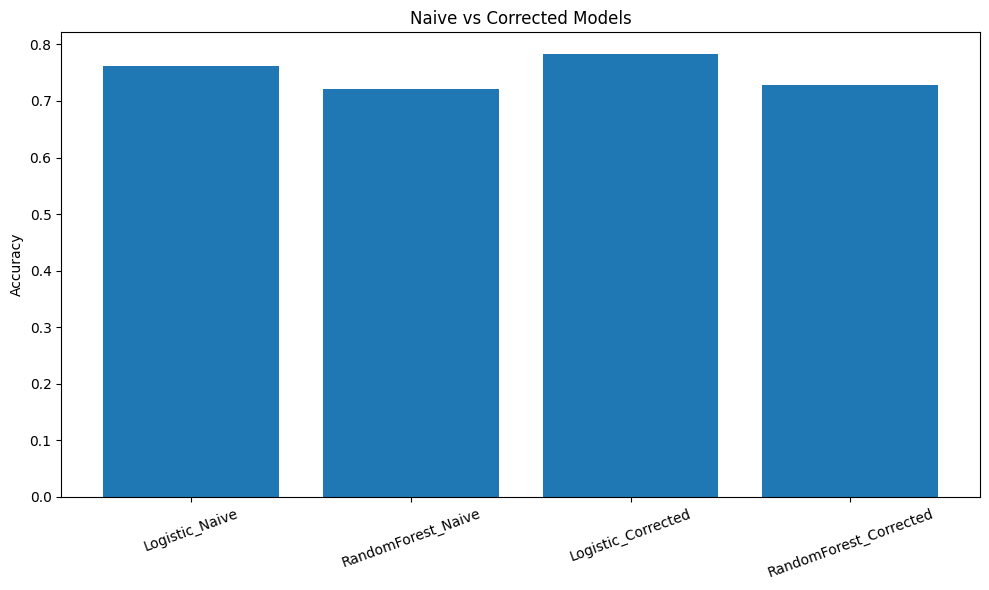

In [14]:
plt.figure(figsize=(10,6))

plt.bar(
    all_results["Model"],
    all_results["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Naive vs Corrected Models"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

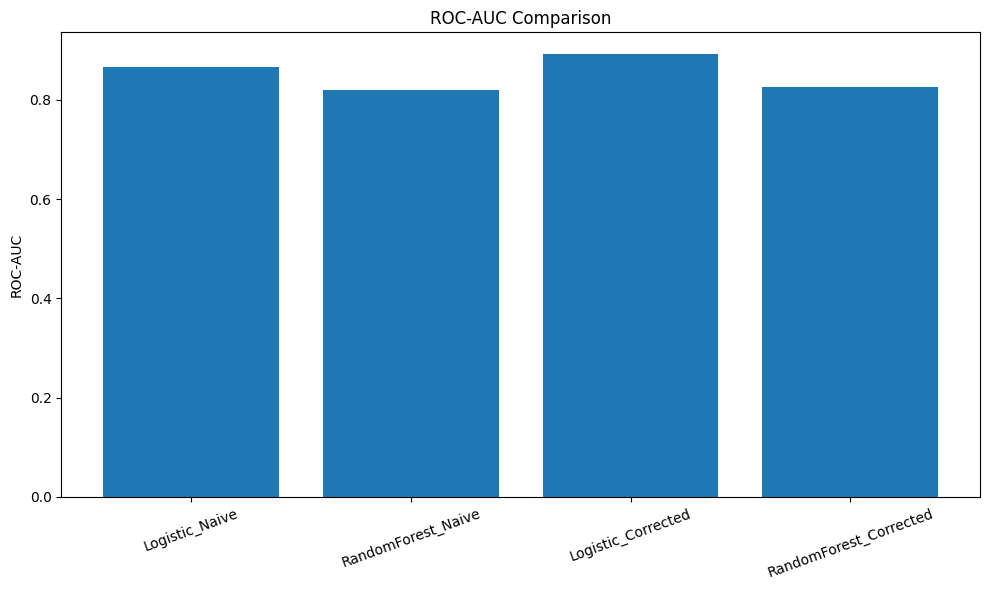

In [15]:
plt.figure(figsize=(10,6))

plt.bar(
    all_results["Model"],
    all_results["ROC_AUC"]
)

plt.ylabel("ROC-AUC")

plt.title(
    "ROC-AUC Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X_corr.columns,
    "Importance": rf_corr.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
4,duration,0.317669
6,lat_range,0.126199
7,lng_range,0.116208
3,formation_breadth,0.113666
1,collection_count,0.095563
0,occurrence_count,0.084869
5,sampling_intensity,0.073212
2,environment_breadth,0.036622
8,lazarus,0.035994


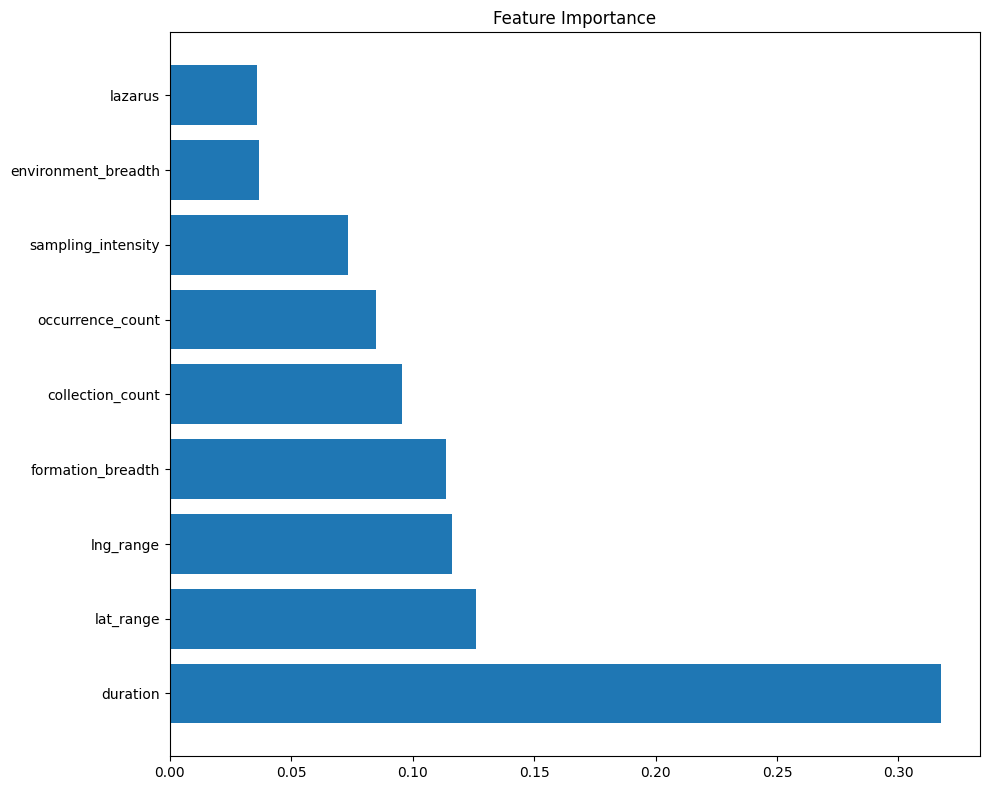

In [17]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.tight_layout()

plt.show()

In [18]:
all_results.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

# Conclusions

1. Sampling-corrected models outperformed naive models.
2. Corrected Logistic Regression achieved the highest performance
   (Accuracy = 78.2%, ROC-AUC = 0.891).
3. Temporal duration was the strongest predictor of survival.
4. Geographic range and formation breadth also strongly influenced survival.
5. Lazarus taxa provided additional predictive information,
   supporting the importance of sampling correction.